In [21]:
import pandas as pd
import EDA_final as eda
import importlib

importlib.reload(eda)

file = r"C:\Users\alexa\Documents\Alexander\NTNU\5 året\ML in natural sciences\ML project – offline\Dataset_before_cleaning\NO1_energy_weather_2019_2025.csv"
df = pd.read_csv(file)

### 1. Final data-quality assessment

In [22]:
eda.data_quality_assessment(df)

Information about the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   timestamp                             61368 non-null  object 
 1   day_ahead_price                       60391 non-null  float64
 2   load_forecast                         61365 non-null  float64
 3   actual_load                           61364 non-null  float64
 4   wind_forecast                         60373 non-null  float64
 5   hydro_run_of_river                    60989 non-null  float64
 6   hydro_reservoir                       61355 non-null  float64
 7   hour                                  61368 non-null  int64  
 8   day_of_week                           61368 non-null  int64  
 9   month                                 61368 non-null  int64  
 10  year                                  61368 non-nu

### 2. Target-variable distribution

Summary Statistics for day_ahead_price:
count    60391.000000
mean        69.748057
std         74.996667
min        -61.840000
25%         28.270000
50%         47.880000
75%         88.250000
max        799.970000
Name: day_ahead_price, dtype: float64

Skewness: 2.9042549167160985
Kurtosis: 12.345365829981116


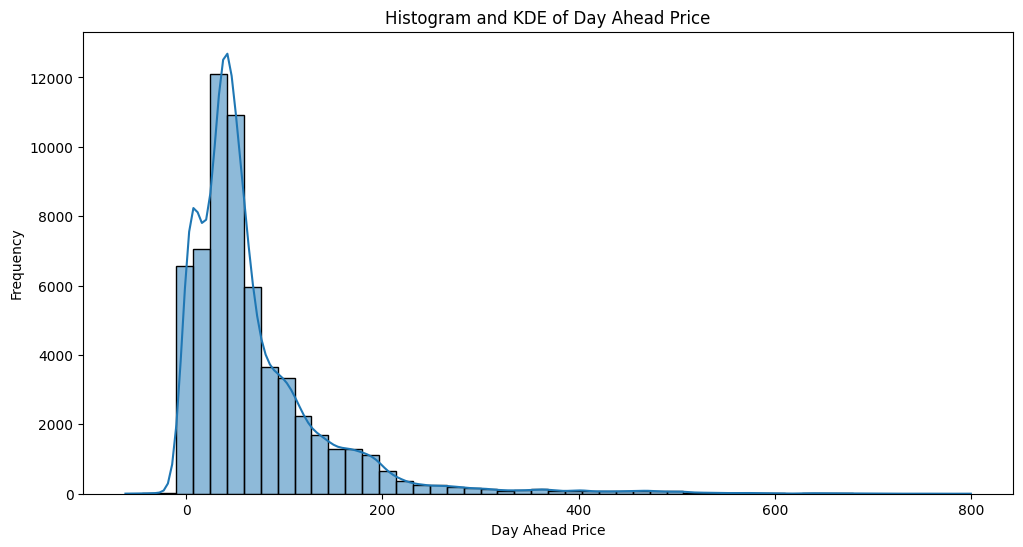

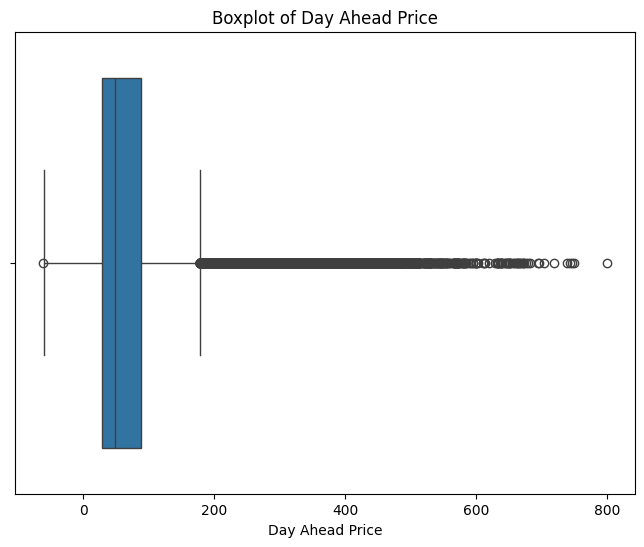

Proportion of negative prices: 1.05%
Proportion of unusually high prices (above 95th percentile): 4.92%


In [23]:
# Analysis of the target variable day ahead price
eda.target_variable_distribution(df)

### 3. Price through time

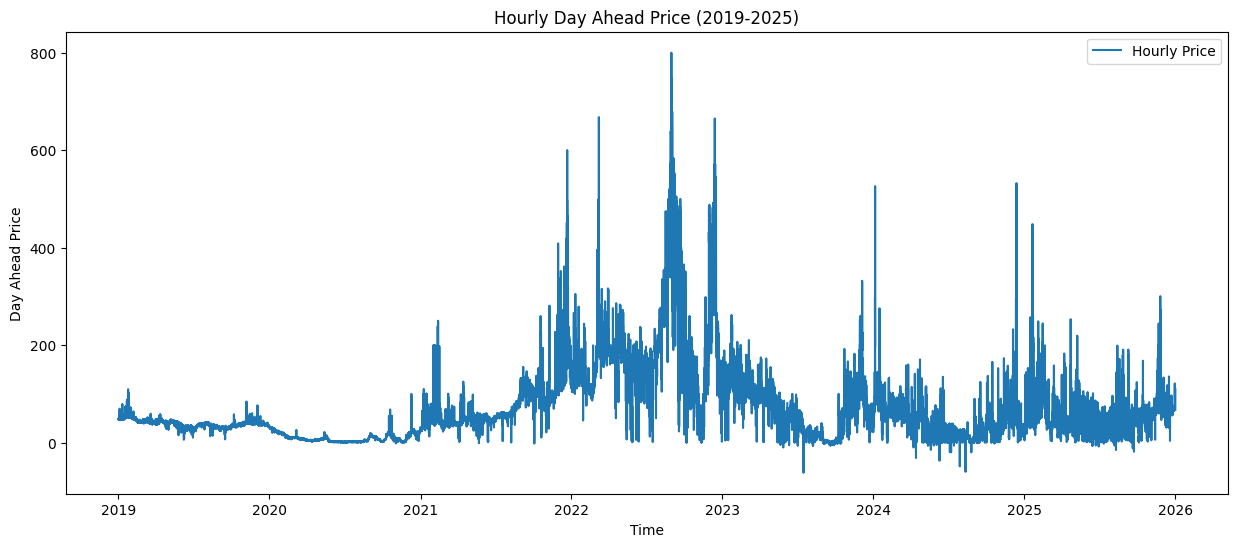

c:\Users\alexa\Documents\Alexander\NTNU\5 året\ML in natural sciences\ML project – offline\EDA_final_data\EDA_final.py:138: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['day_ahead_price'].resample('M').mean()


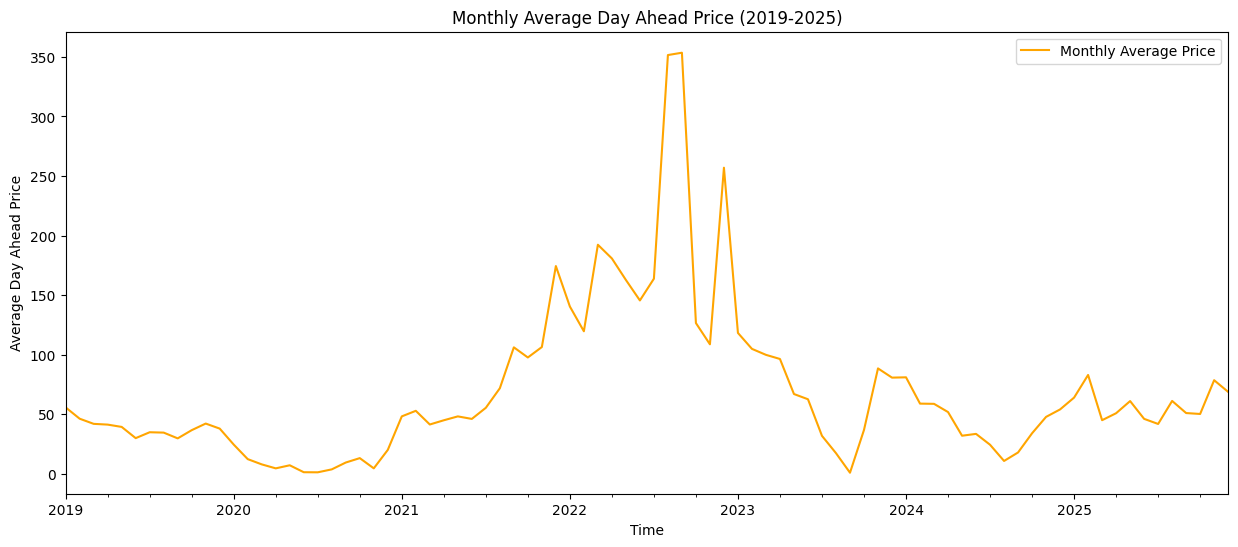

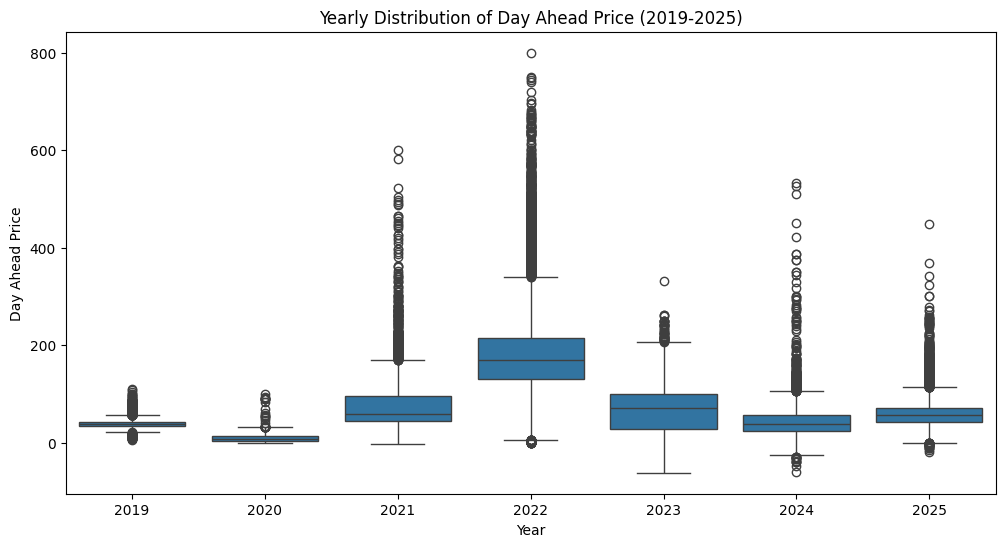

Yearly Descriptive Statistics for Day Ahead Price:
       count        mean         std    min       25%       50%         75%  \
year                                                                          
2019  8656.0   39.296978    8.369145   5.86   34.0900   38.8250   42.920000   
2020  8224.0    9.678800    8.323869  -1.73    2.7050    7.4700   14.110000   
2021  8704.0   74.778956   47.859732  -1.97   45.2200   58.3850   95.045000   
2022  8730.0  192.484164  109.802120   0.04  130.9825  168.9100  214.795000   
2023  8655.0   67.422616   44.501993 -61.84   27.2350   70.6000   99.090000   
2024  8672.0   42.291097   33.439632 -59.96   22.9800   37.9300   56.240000   
2025  8750.0   58.382616   32.657179 -18.75   41.5750   56.2875   70.209375   

         max  
year          
2019  109.45  
2020   99.92  
2021  600.16  
2022  799.97  
2023  332.00  
2024  532.26  
2025  448.28  


In [24]:
# Plotting the day ahead price thorughout the years 2019-2025

eda.plot_price_through_time(df)

### 4. Seasonality and calendar patterns 

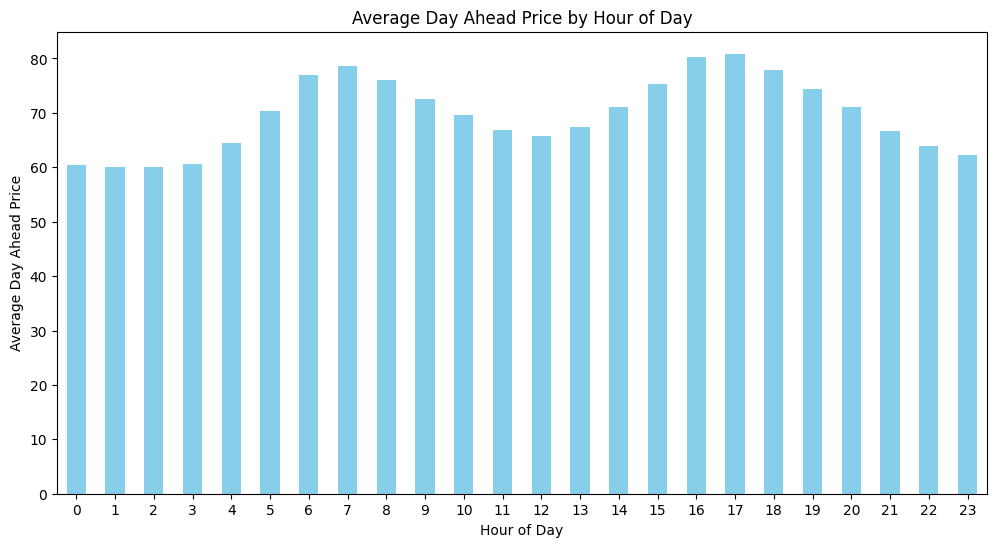

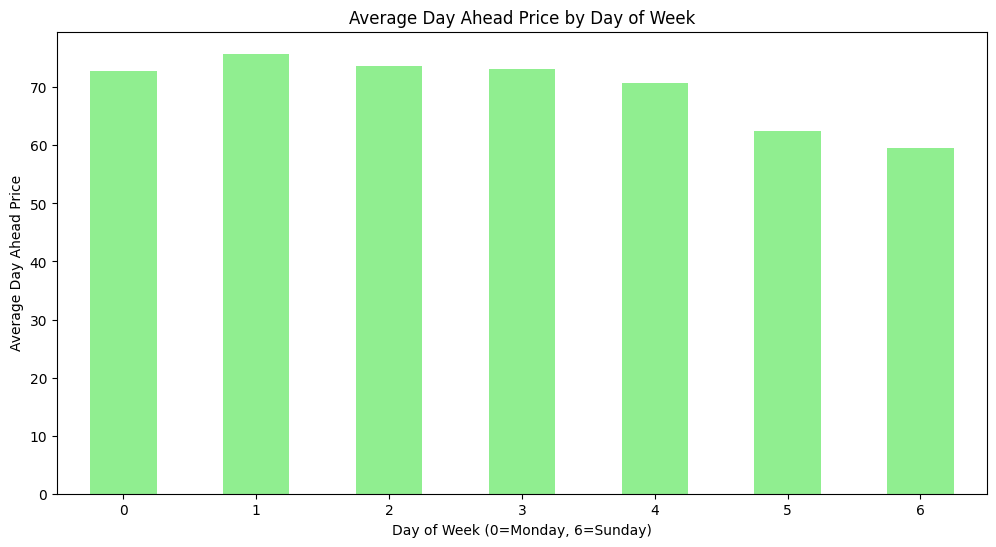

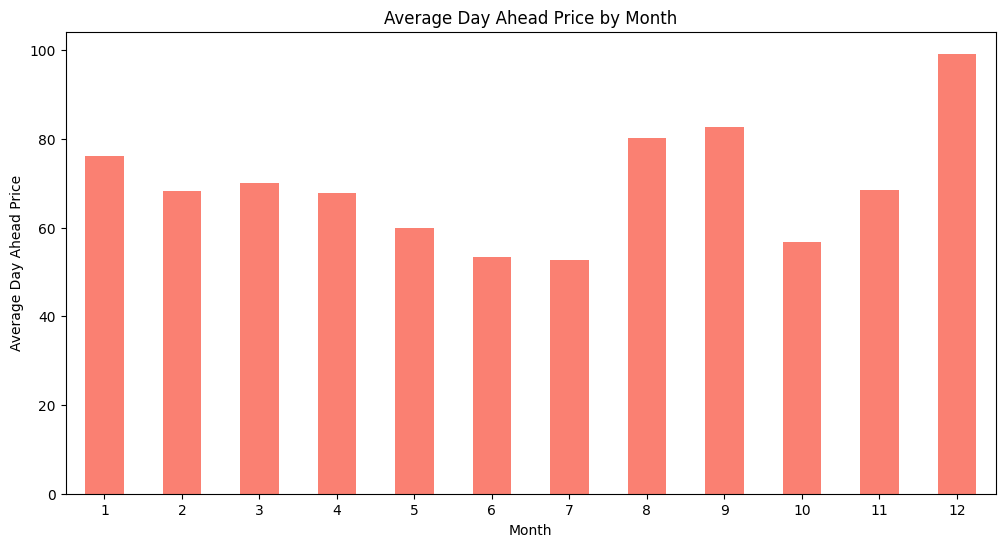

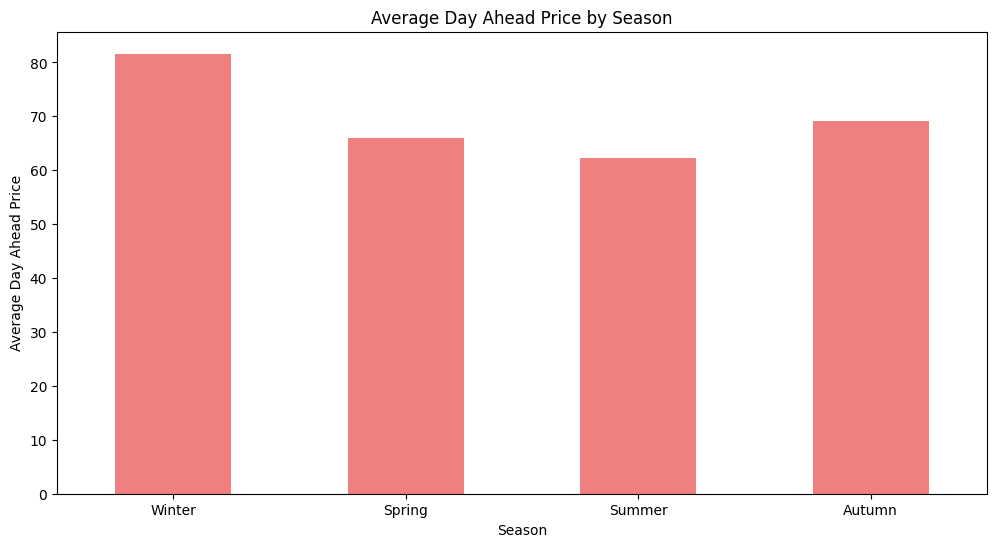

In [25]:
eda.seasonality_and_calendar_patterns(df)

### 5. Temperature Analysis

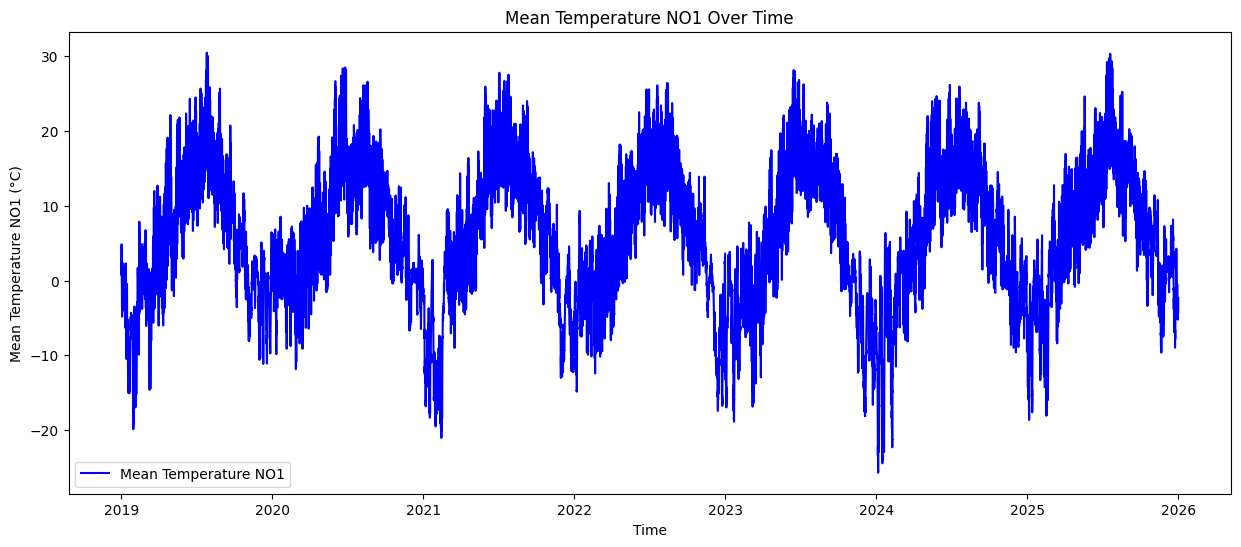

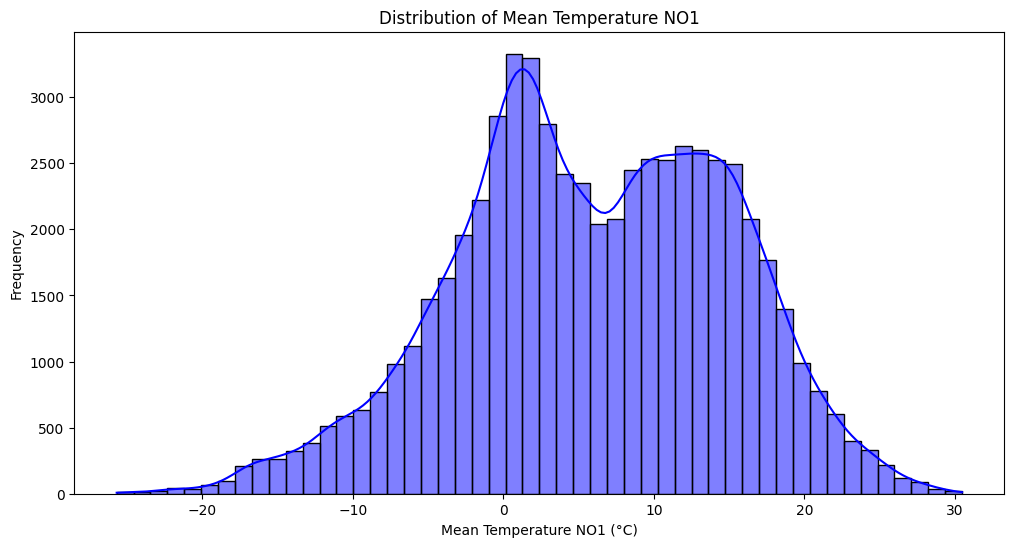

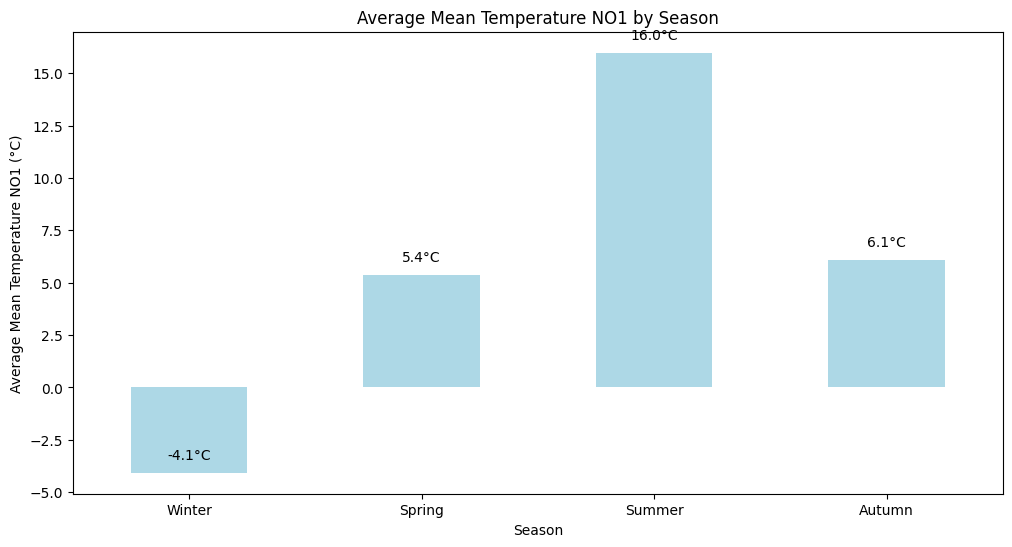

In [26]:
eda.temperature_analysis(df)

### 6. Price-temperature relationship and Load-temperature relationship

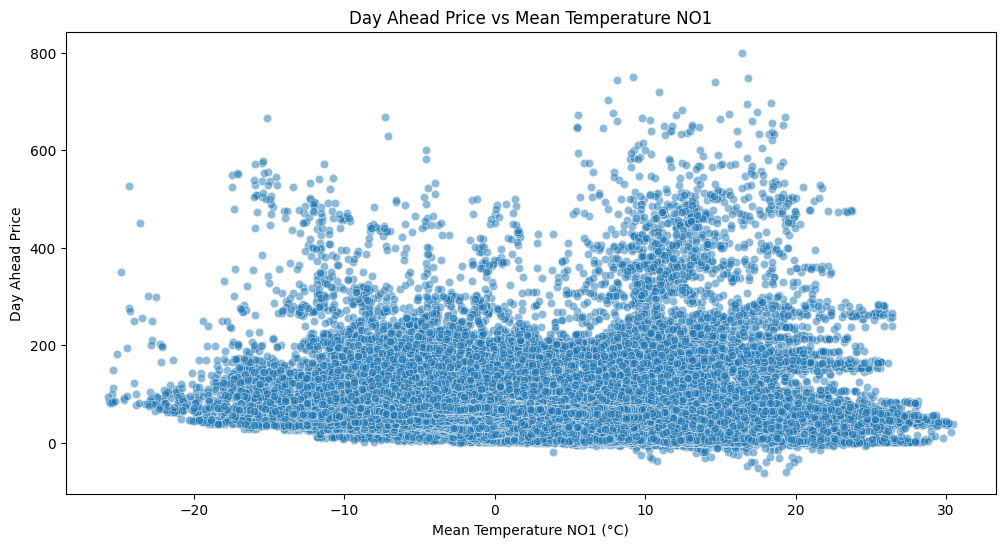

c:\Users\alexa\Documents\Alexander\NTNU\5 året\ML in natural sciences\ML project – offline\EDA_final_data\EDA_final.py:345: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = df.groupby('temp_bin')['day_ahead_price'].median()


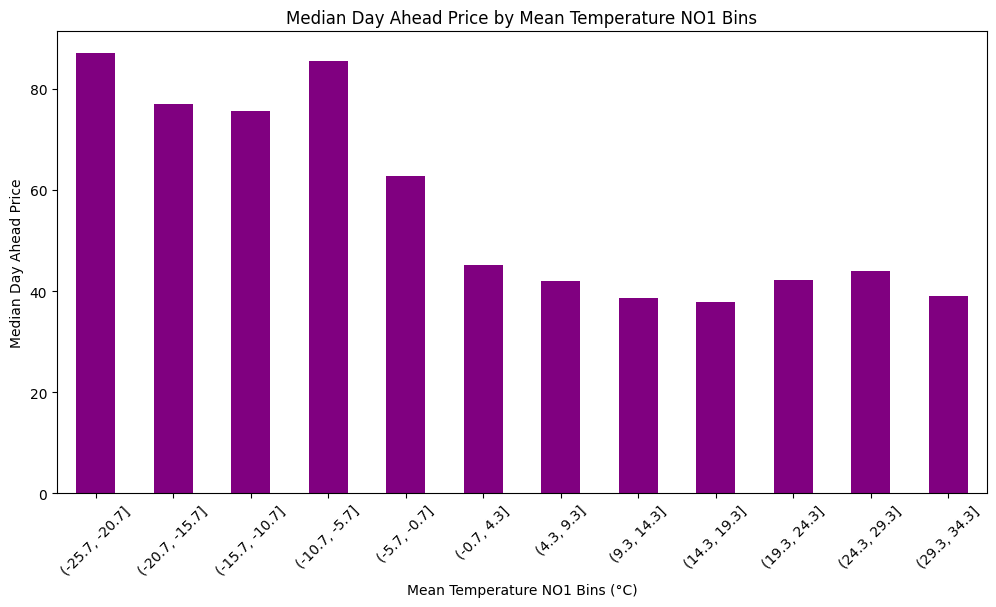

Correlation between day_ahead_price and mean_temperature_NO1: -0.1385


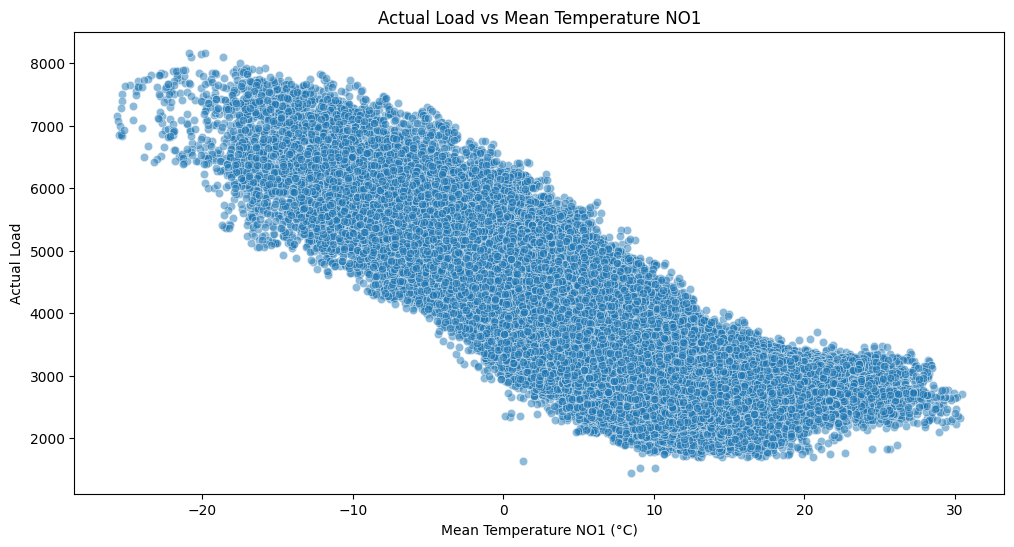

c:\Users\alexa\Documents\Alexander\NTNU\5 året\ML in natural sciences\ML project – offline\EDA_final_data\EDA_final.py:383: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_loads = df.groupby('temp_bin')['actual_load'].median()


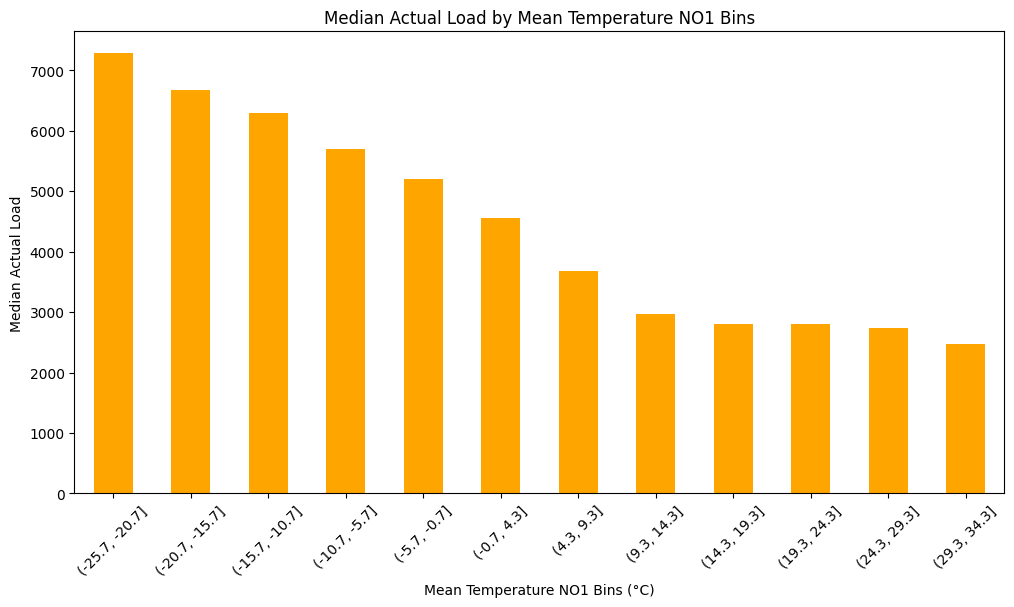

Correlation between actual_load and mean_temperature_NO1: -0.8394


In [27]:
eda.price_temperature_relationship(df)
eda.load_temperature_relationship(df)

### 7. Price relationships with the energy variables

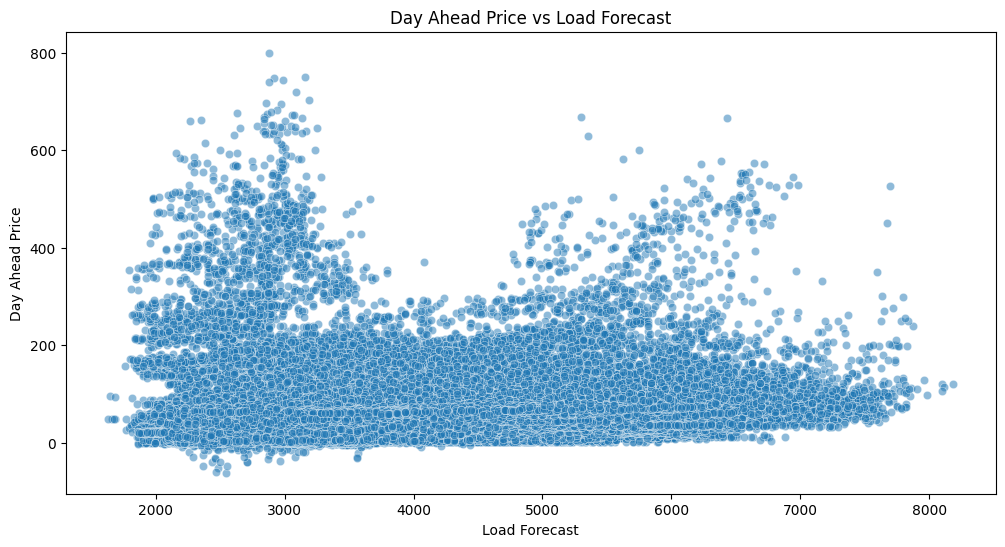

Correlation between day_ahead_price and load_forecast: 0.0913


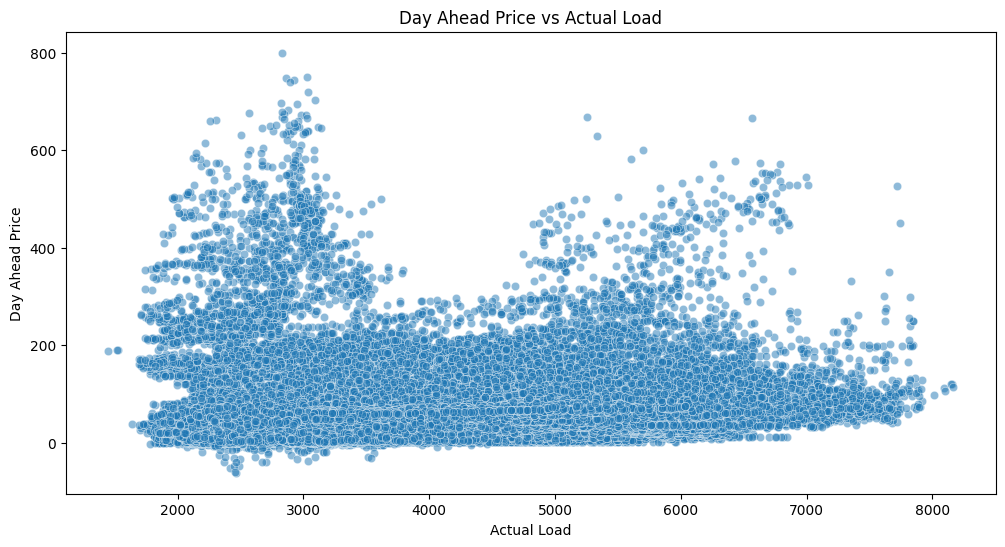

Correlation between day_ahead_price and actual_load: 0.0859


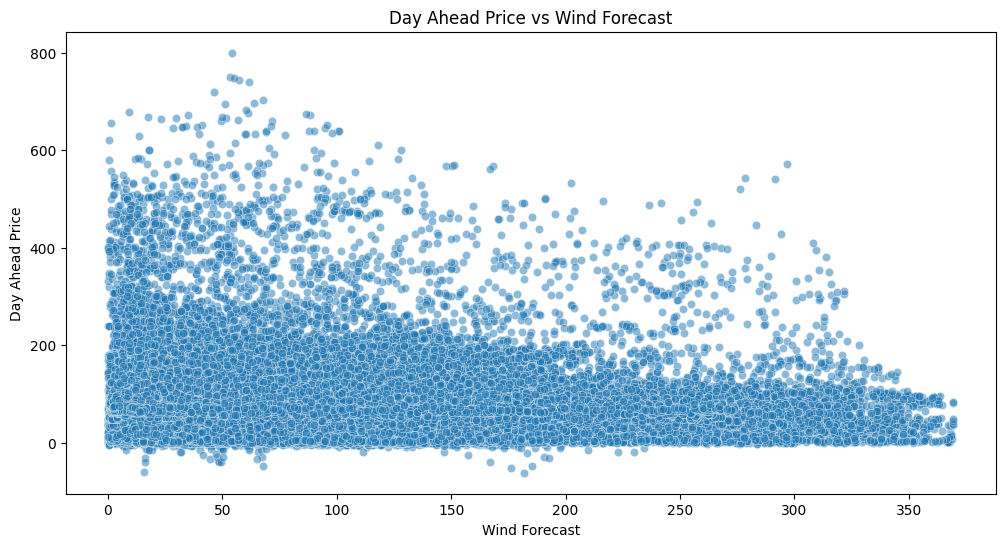

Correlation between day_ahead_price and wind_forecast: -0.0013


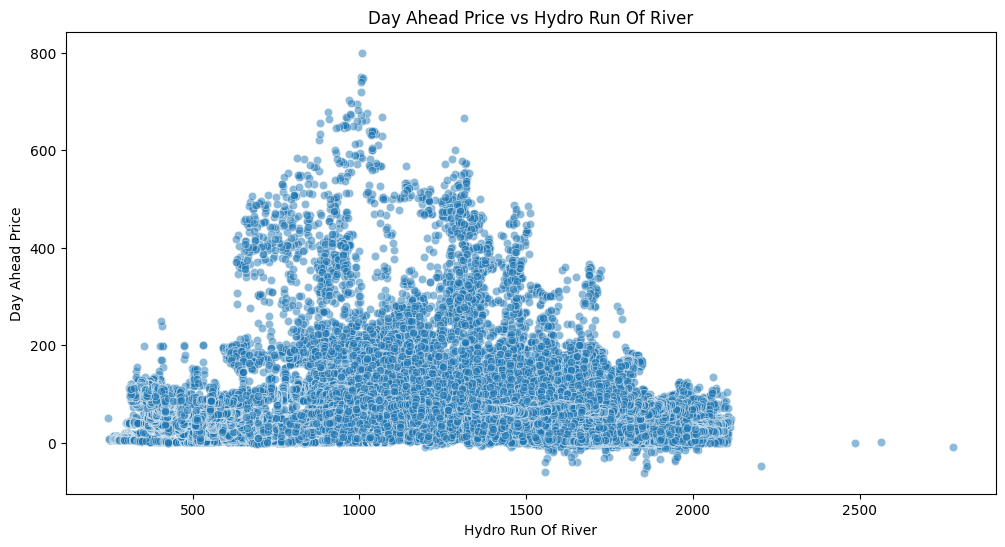

Correlation between day_ahead_price and hydro_run_of_river: 0.0378


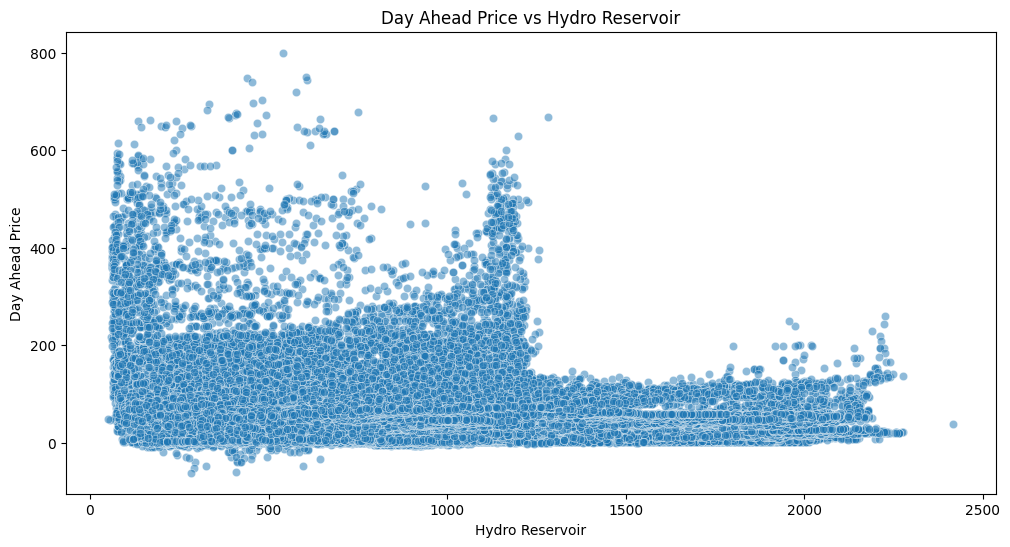

Correlation between day_ahead_price and hydro_reservoir: -0.3154


In [28]:
eda.price_energy_relationships(df)

8. Correlation Matrices

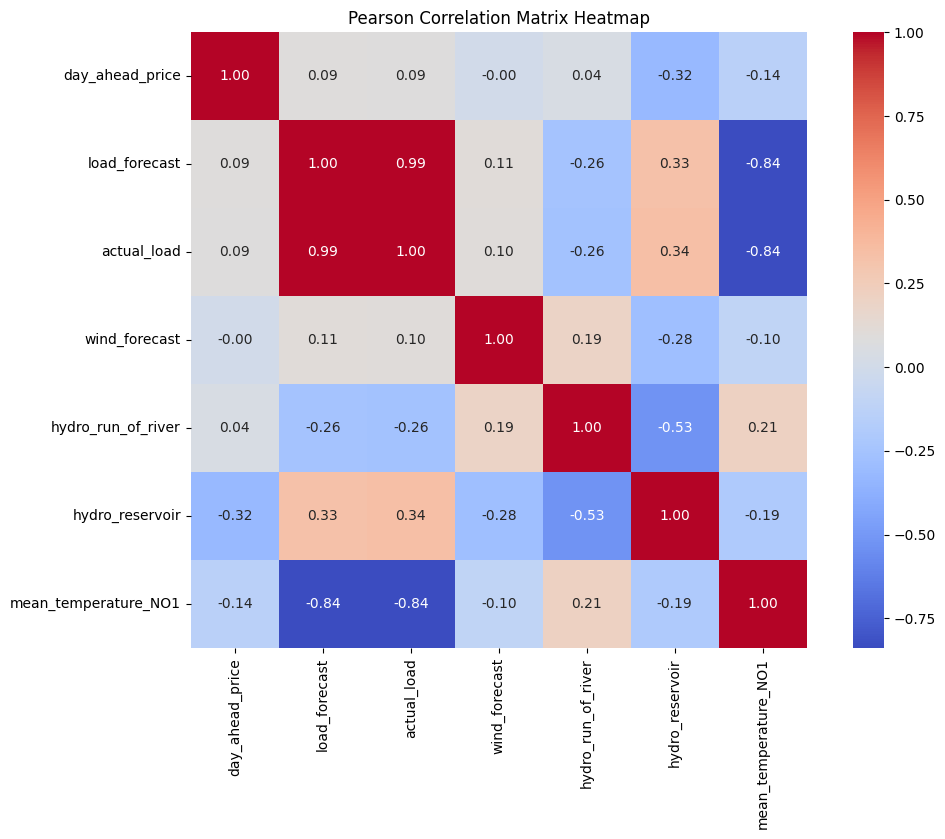

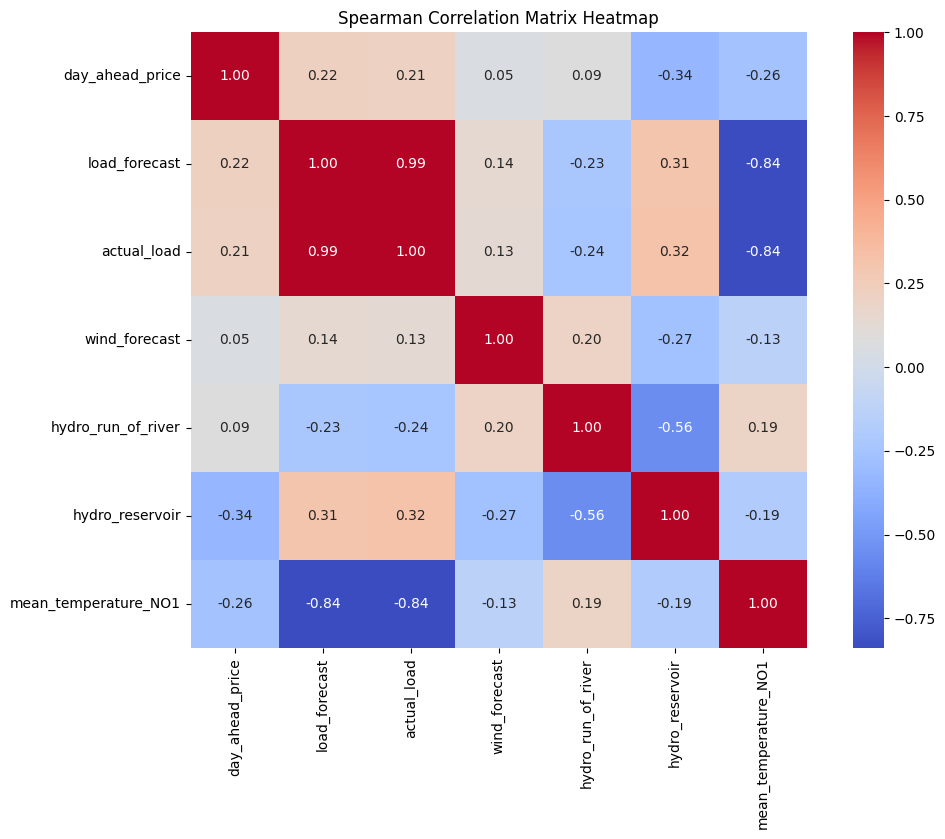

In [29]:
eda.correlation_matrix_heatmap(df)

### 9. Forecast-vs-actual load analysis

Mean Absolute Error (MAE): 85.40
Root Mean Squared Error (RMSE): 152.35
Standard Deviation of Load Error: 152.13
Correlation between actual load and forecast: 0.9929


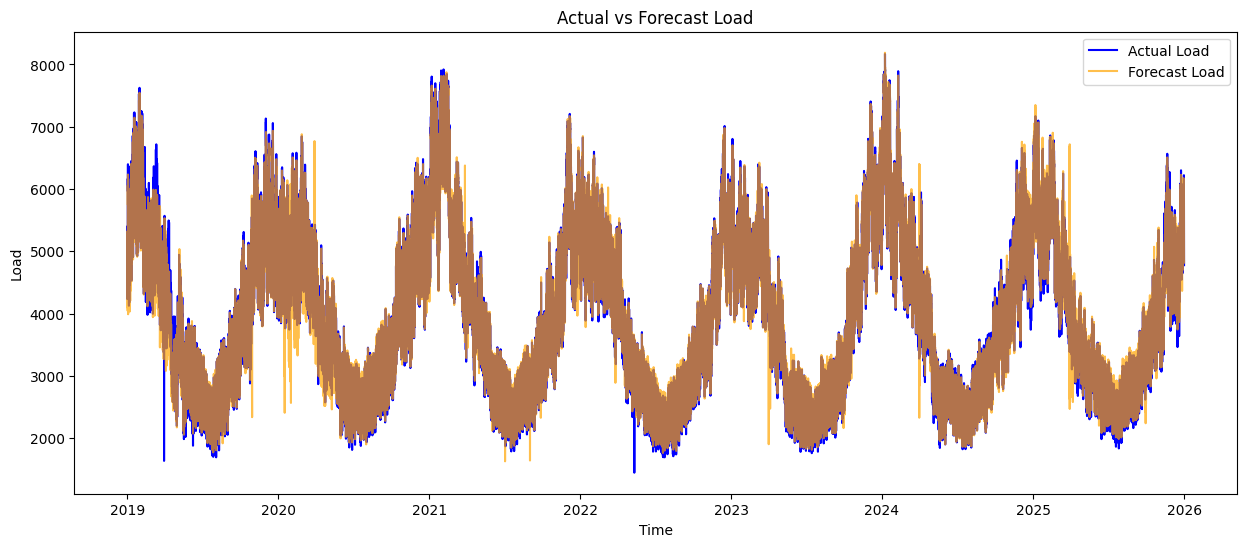

In [30]:
eda.forecast_vs_actual_load_analysis(df)

### 10. Mutual information table

c:\Users\alexa\Documents\Alexander\NTNU\5 året\ML in natural sciences\ML project – offline\EDA_final_data\EDA_final.py:616: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_results['MI'], y=mi_results.index, palette='viridis')


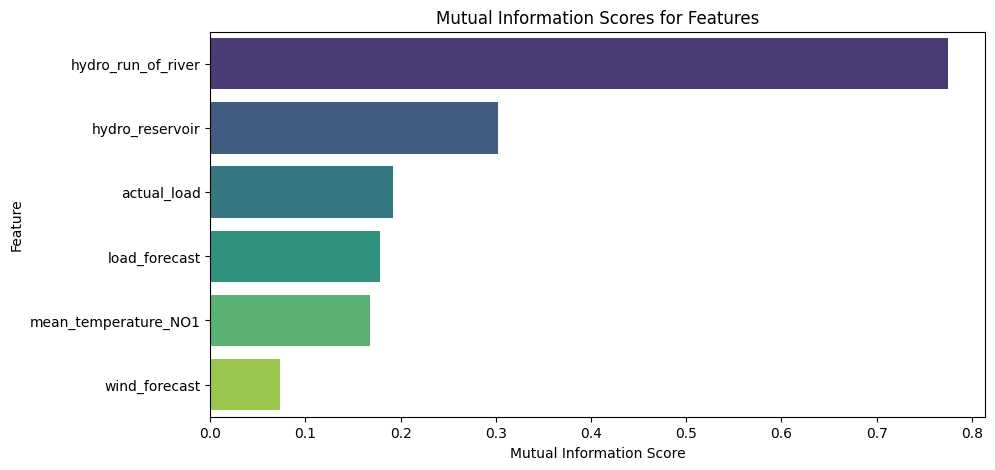

                            MI
hydro_run_of_river    0.775342
hydro_reservoir       0.302315
actual_load           0.191465
load_forecast         0.178583
mean_temperature_NO1  0.168207
wind_forecast         0.073726


In [31]:
df = df.copy()

features = [
    'load_forecast',
    'actual_load',
    'wind_forecast',
    'hydro_run_of_river',
    'hydro_reservoir',
    'mean_temperature_NO1'
]

valid = df[features + ['day_ahead_price']].dropna()

mi_results = eda.mutual_information_table(
    valid[features],
    target=valid['day_ahead_price'],
    continuous=features
)

print(mi_results)

### 11. Extreme price analysis

Number of extreme price observations: 1205
Number of ordinary price observations: 59186


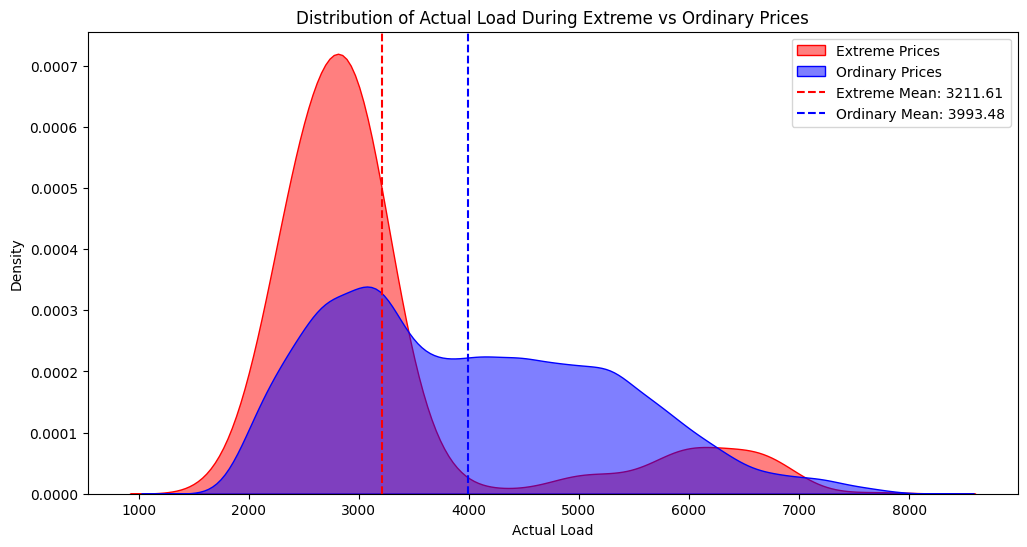

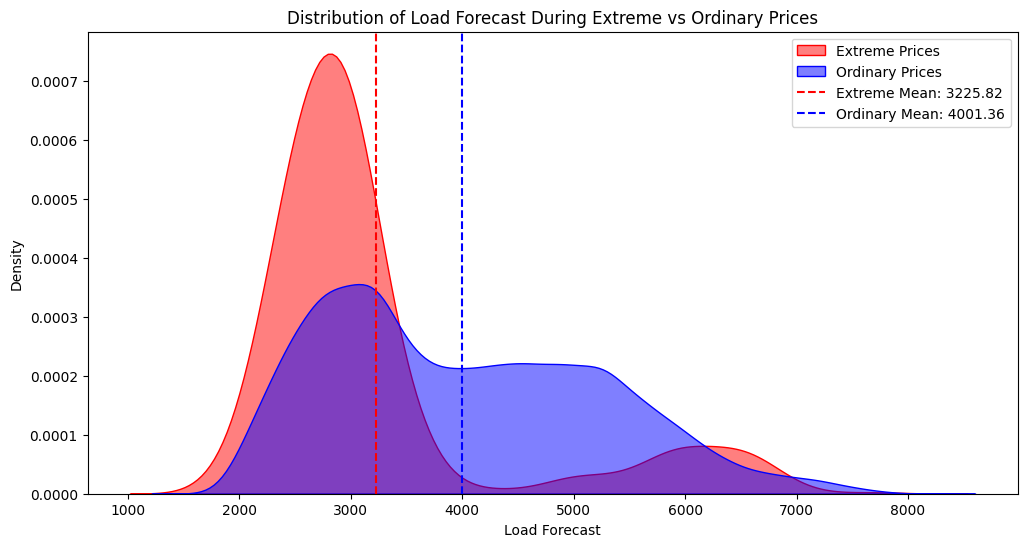

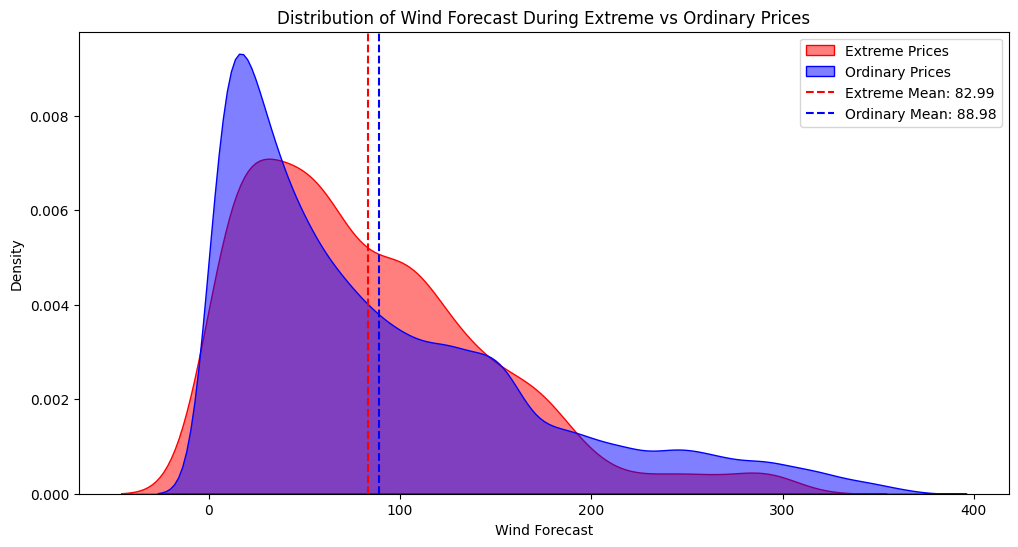

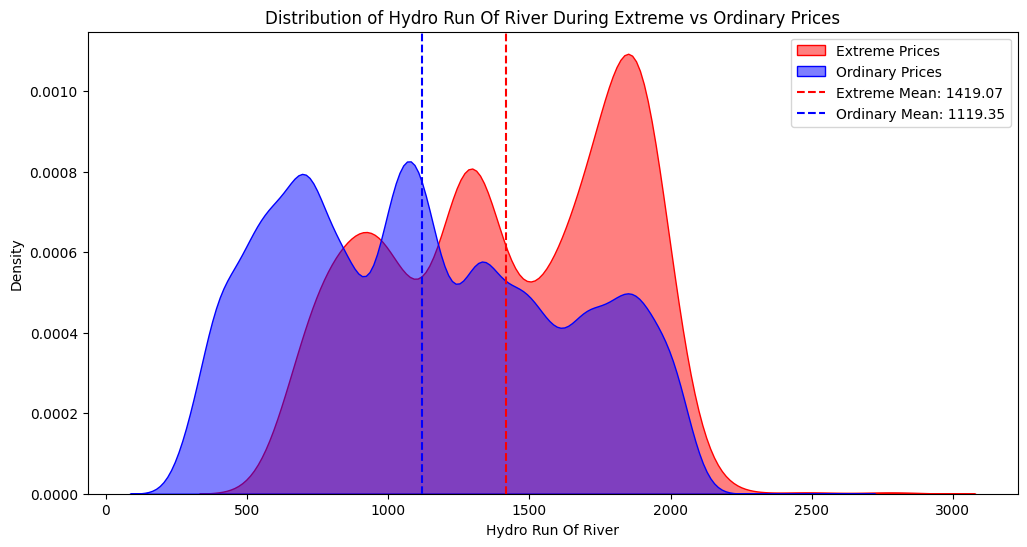

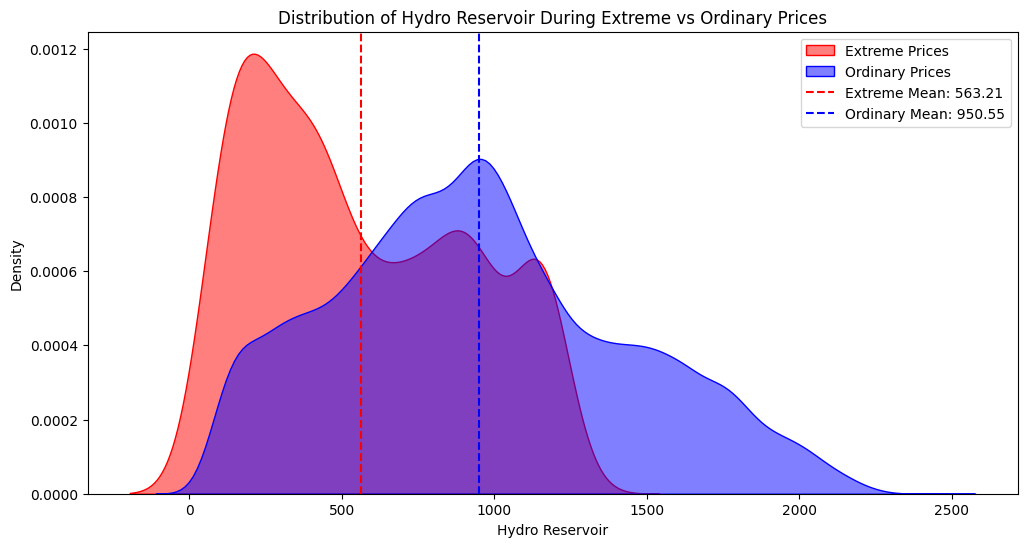

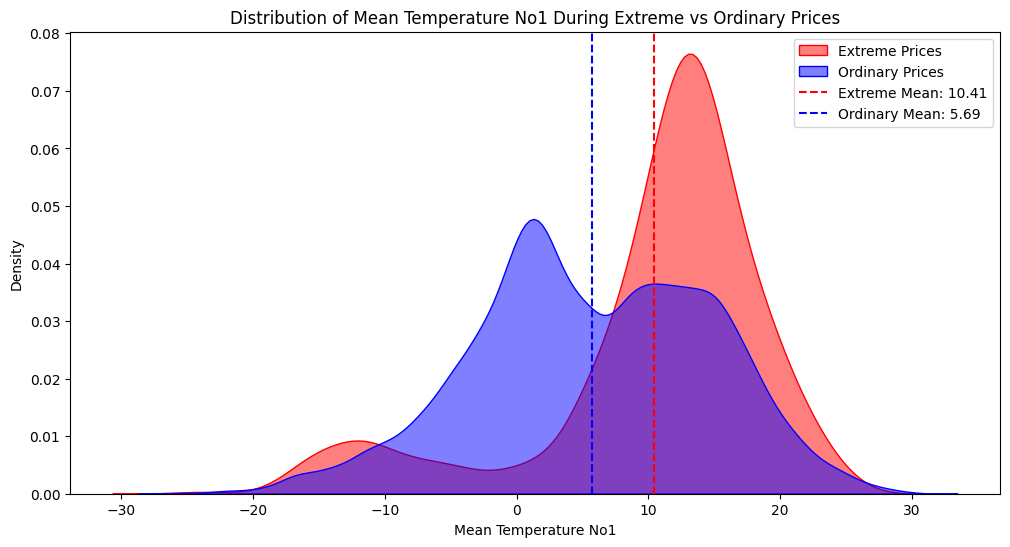

In [32]:
eda.extreme_price_analysis(df)

### 12. Annual Changes

Annual Statistics for Day Ahead Price:
            mean    median         std    min     max
year                                                 
2019   39.296978   38.8250    8.369145   5.86  109.45
2020    9.678800    7.4700    8.323869  -1.73   99.92
2021   74.778956   58.3850   47.859732  -1.97  600.16
2022  192.484164  168.9100  109.802120   0.04  799.97
2023   67.422616   70.6000   44.501993 -61.84  332.00
2024   42.291097   37.9300   33.439632 -59.96  532.26
2025   58.382616   56.2875   32.657179 -18.75  448.28


<Figure size 1200x600 with 0 Axes>

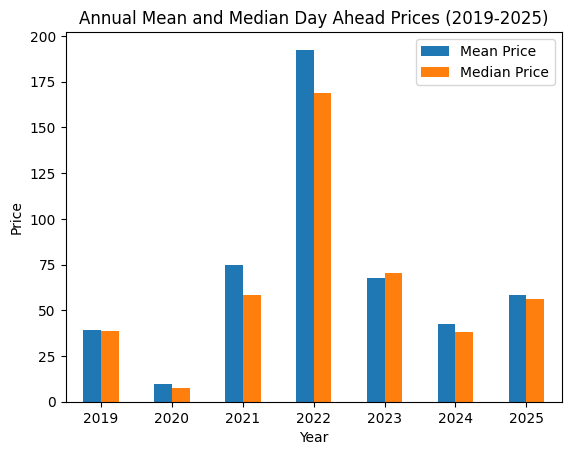

In [33]:
eda.annual_changes(df)

### 13. Outlier investigation

Number of price outliers: 1205


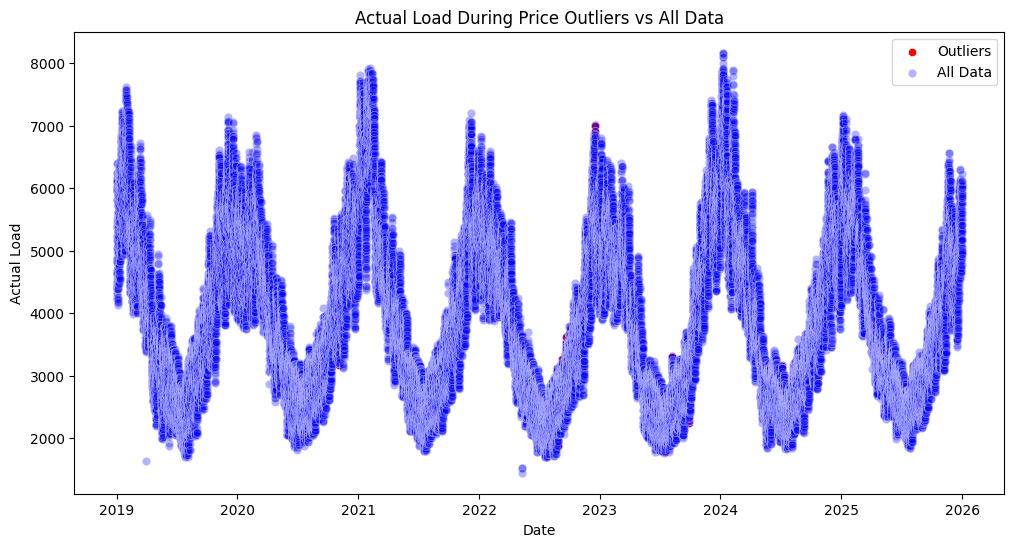

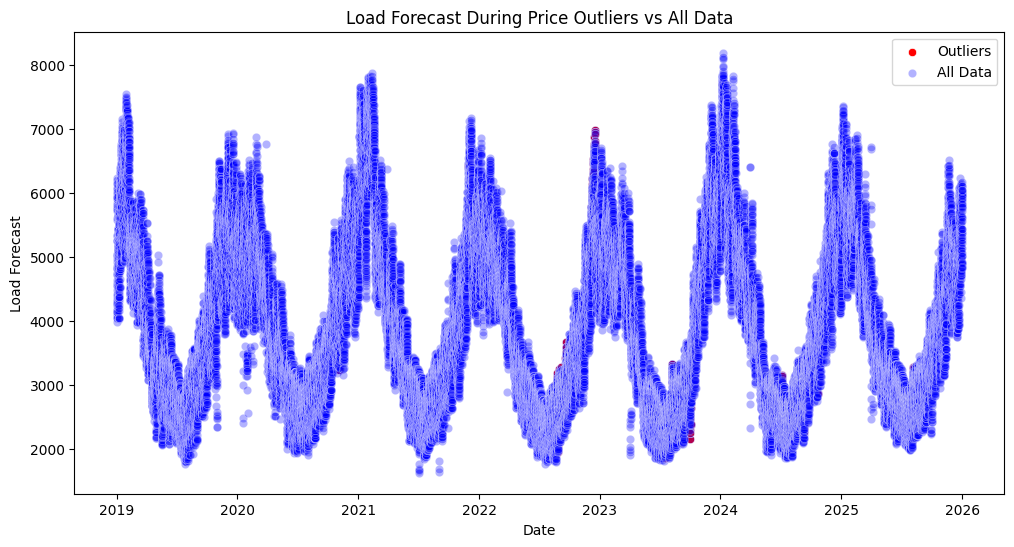

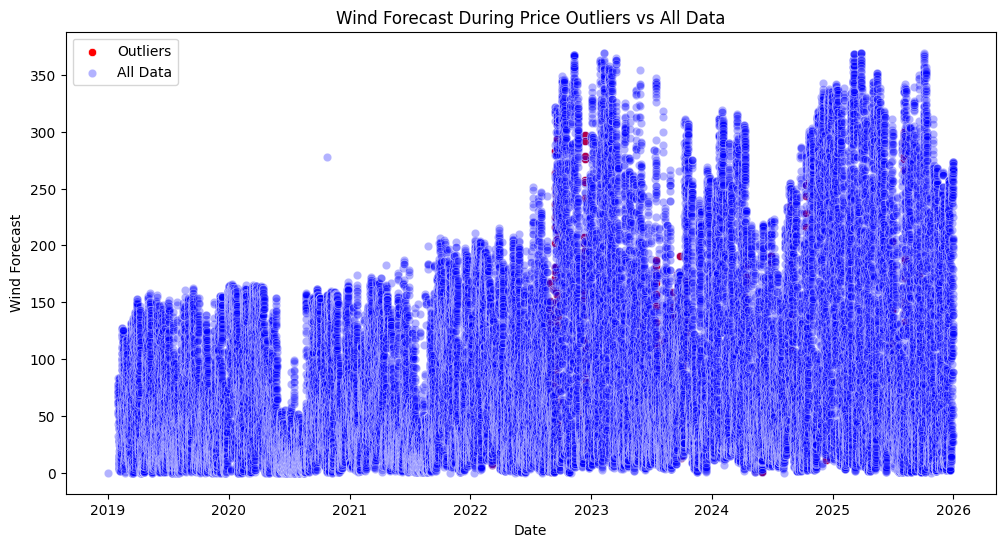

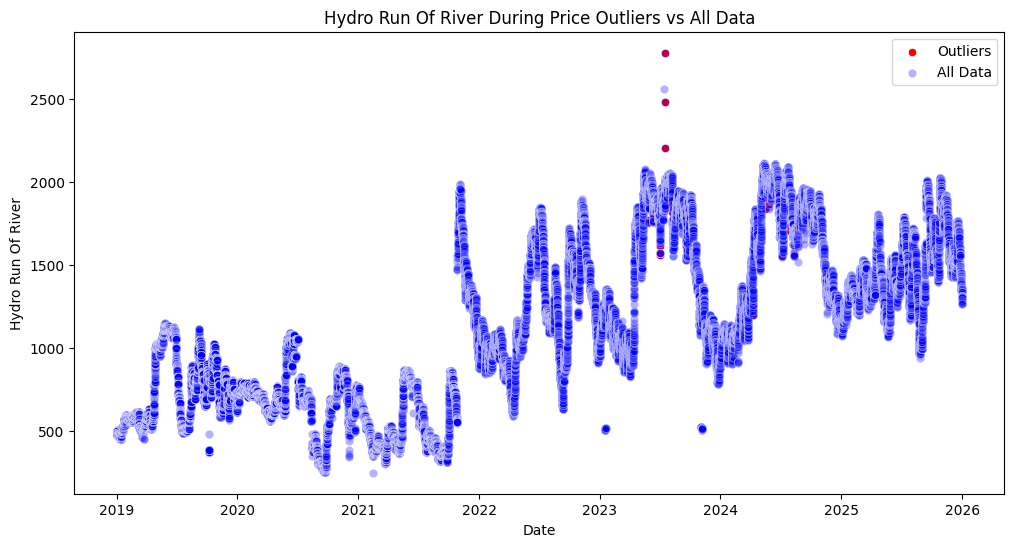

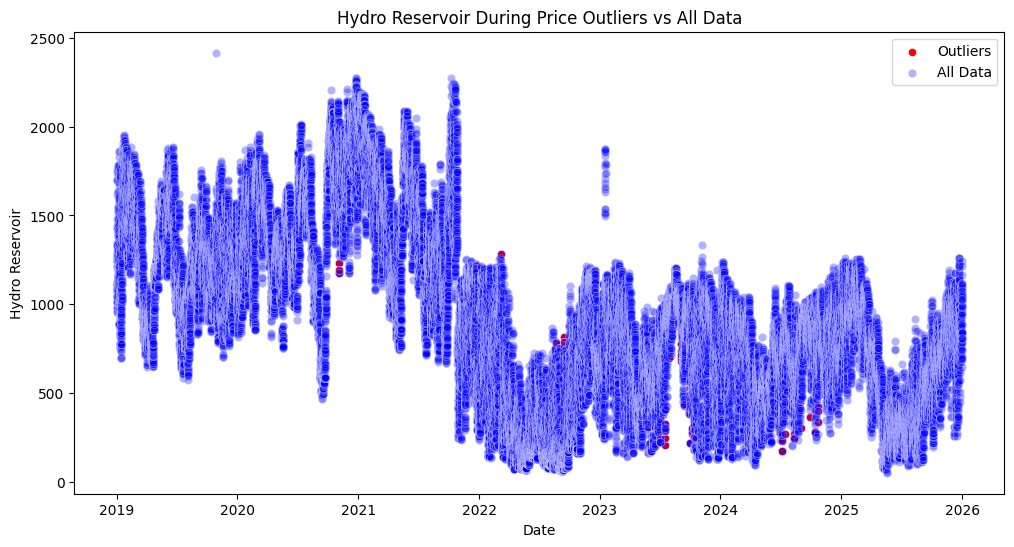

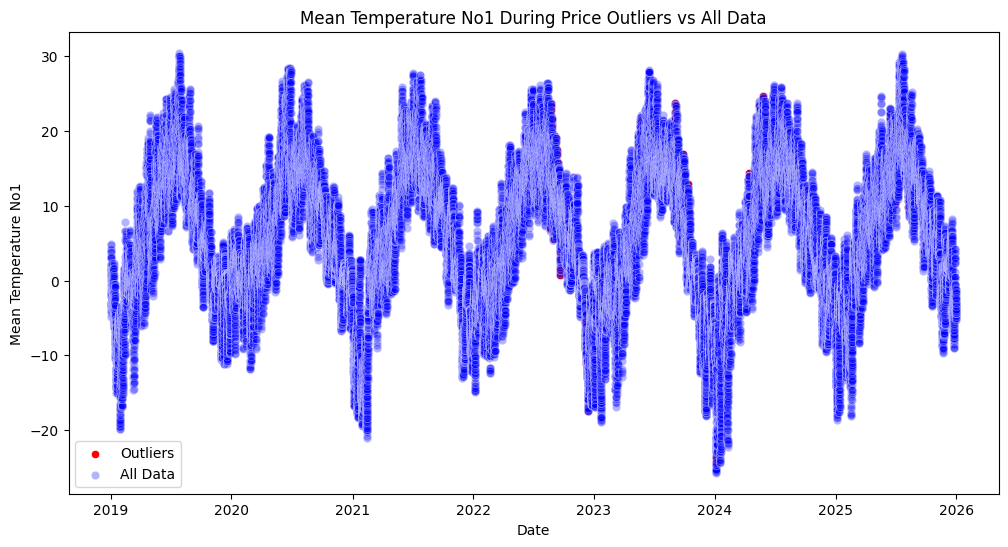

In [34]:
eda.outlier_investigation(df)

### 14. Checking training/validation/test split

Training set: 43801 observations
Validation set: 8784 observations
Test set: 8783 observations


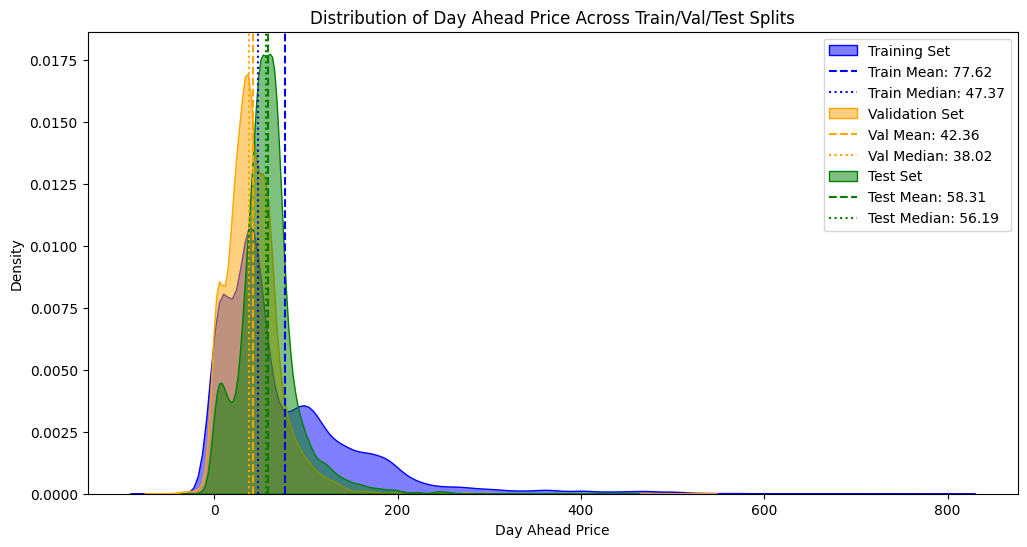

In [35]:

#Training data between 2019-2023
# Validation data between 2024
# Test data between 2025
train_end = '2023-12-31'
val_end = '2024-12-31'
eda.check_train_val_test_split(df, train_end, val_end)

### Creating final ML dataset: 

In [36]:
#import Data_cleaning as dc
#importlib.reload(dc)

#dc.clean_df(df)

In [37]:
#importlib.reload(dc)

#model_file = r"C:\\Users\\alexa\\Documents\\Alexander\\NTNU\\5 året\\ML in natural sciences\\ML project – offline\\EDA_final_data\\NO1_ML_dataset_2019_2025.csv"
#model_df = pd.read_csv(model_file)

#dc.check_cleaned_data(df, model_df)
